# Online Retail Store

## Secnarij
1. Koje tipove kupaca imamo? - Clustering
2. Hoce li kupac i dalje ostati u trgovini? - Klasifikacija
3. Koliki prihod mozemo ocekivati od kupca u buducem razdoblju? - Regresija


**Dataset**
UCI Online Retails Dataset (https://archive.ics.uci.edu/)

https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

Redoslijed koarak u procesu:
1. ucitavanje podataka
2. razumijevanje podataka
3. ciscenje
4. feature engineering
5. vizualizacije
6. clustering
7. klasifikacija
8. regresija
9. zakljucak

## 1. Uvoz podataka

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (accuracy_score, mean_absolute_error, r2_score)

pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

In [9]:
df = pd.read_excel('data/Online Retail.xlsx')
df.head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,"13,047.00",United Kingdom


## 2. Pregled podataka

In [10]:
df.shape

(541909, 8)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [12]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


## 3 Ciscenje podataka

In [14]:
df_clean = df.copy()

In [15]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [16]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [21]:
# Filtriramo sve racune koji pocinju s C jer je to oznaka za Canceled
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

In [22]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [23]:
df_clean.duplicated().sum()

np.int64(5192)

In [24]:
df_clean = df_clean.drop_duplicates()

In [25]:
df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [26]:
df_clean[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,"392,692.00","392,692.00"
mean,13.12,3.13
std,180.49,22.24
min,1.00,0.00
25%,2.00,1.25
50%,6.00,1.95
75%,12.00,3.75
max,"80,995.00","8,142.75"


## 4. Feature engineering

Kreiramo novi stupac ukupna cijena stavke na osnovu podataka iz kolicine i jedinicne vrijednosti

In [28]:
df_clean['LineTotal'] = df_clean.Quantity * df_clean.UnitPrice
# df_clean['LineTotal'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'LineTotal']].head(15)

,Quantity,UnitPrice,LineTotal
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


## 5. Osnovna poslovna analiza

- ukupni prihod
- koje zemlje dominiraju
- kako se prihod mijenja kroz vrijeme
- koji proizvodi se najvise prodaju

In [31]:
total_revenue = df_clean['LineTotal'].sum()
print(f'Ukupan prihod: {total_revenue:,.3f}')

number_of_customers = df_clean['CustomerID'].nunique()
print(f'Broj kupaca: {number_of_customers:,.3f}')

number_of_invoices = df_clean['InvoiceNo'].nunique()
print(f'Broj izdanih racuna: {number_of_invoices:,.3f}')

Ukupan prihod: 8,887,208.894
Broj kupaca: 4,338.000
Broj izdanih racuna: 18,532.000


In [32]:
top_ten_countries = (
    df_clean
    .groupby('Country')['LineTotal']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ten_countries

Country
United Kingdom   7,285,024.64
Netherlands        285,446.34
EIRE               265,262.46
Germany            228,678.40
France             208,934.31
Australia          138,453.81
Spain               61,558.56
Switzerland         56,443.95
Belgium             41,196.34
Sweden              38,367.83
Name: LineTotal, dtype: float64

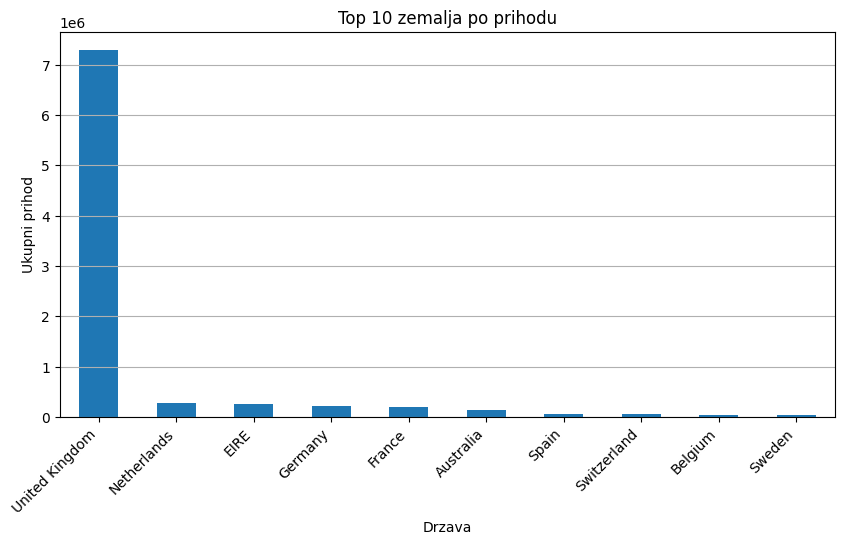

In [35]:
top_ten_countries.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 zemalja po prihodu'
)

plt.xlabel('Drzava')
plt.ylabel('Ukupni prihod')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

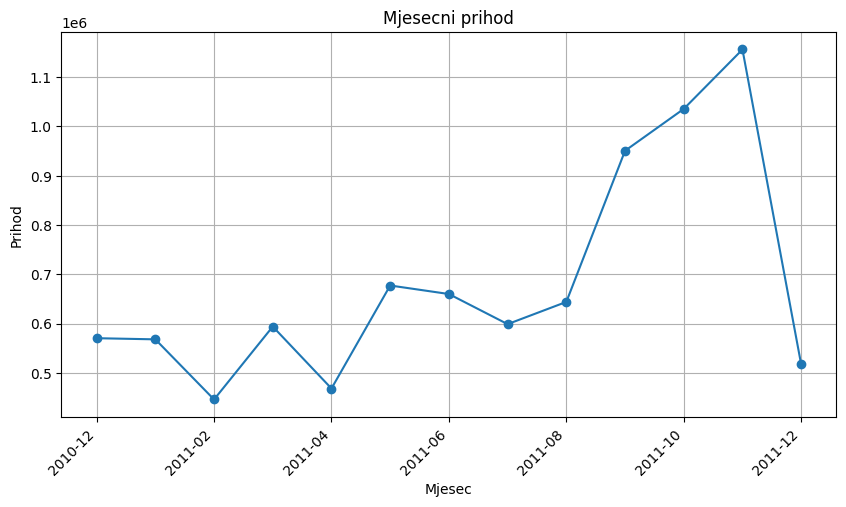

In [39]:
# Dodali smo novi stupac u kojem cemo imati podatke na mjesecnoj razini
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue = df_clean.groupby('InvoiceMonth')['LineTotal'].sum()

monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    title='Mjesecni prihod'
)

plt.xlabel('Mjesec')
plt.ylabel('Prihod')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

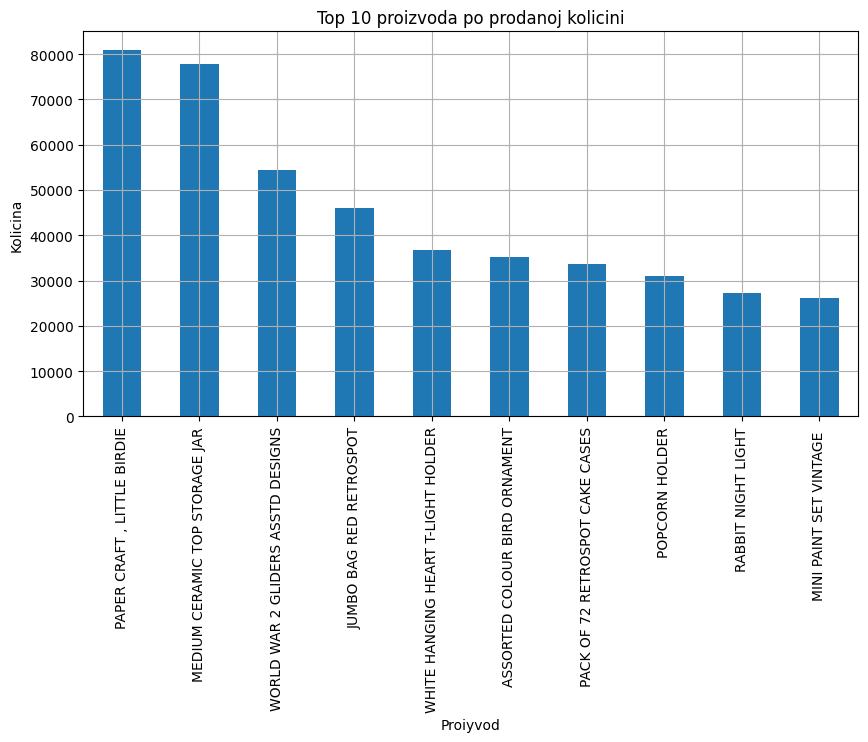

In [42]:
top_ten_products = (
    df_clean
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ten_products.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 proizvoda po prodanoj kolicini'
)

plt.xlabel('Proiyvod')
plt.ylabel('Kolicina')
plt.grid(True)
plt.show()